In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [27]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [28]:
from sklearn.preprocessing import LabelEncoder
one= LabelEncoder()
df['species']=one.fit_transform(df['species'])

In [29]:
df['species']

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64

In [30]:
# independent and independent
x=df.drop(columns=['species'],axis=1)
y=df['species']
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [31]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=10)

In [32]:
from sklearn.tree import DecisionTreeClassifier
#postprunning
dtc=DecisionTreeClassifier(max_depth=2)
dtc.fit(xtrain,ytrain)
y_pered=dtc.predict(xtest)

In [33]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_pered,ytest))
print(classification_report(y_pered,ytest))


[[11  0  0]
 [ 0 15  1]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.94      0.97        16
           2       0.92      1.00      0.96        11

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



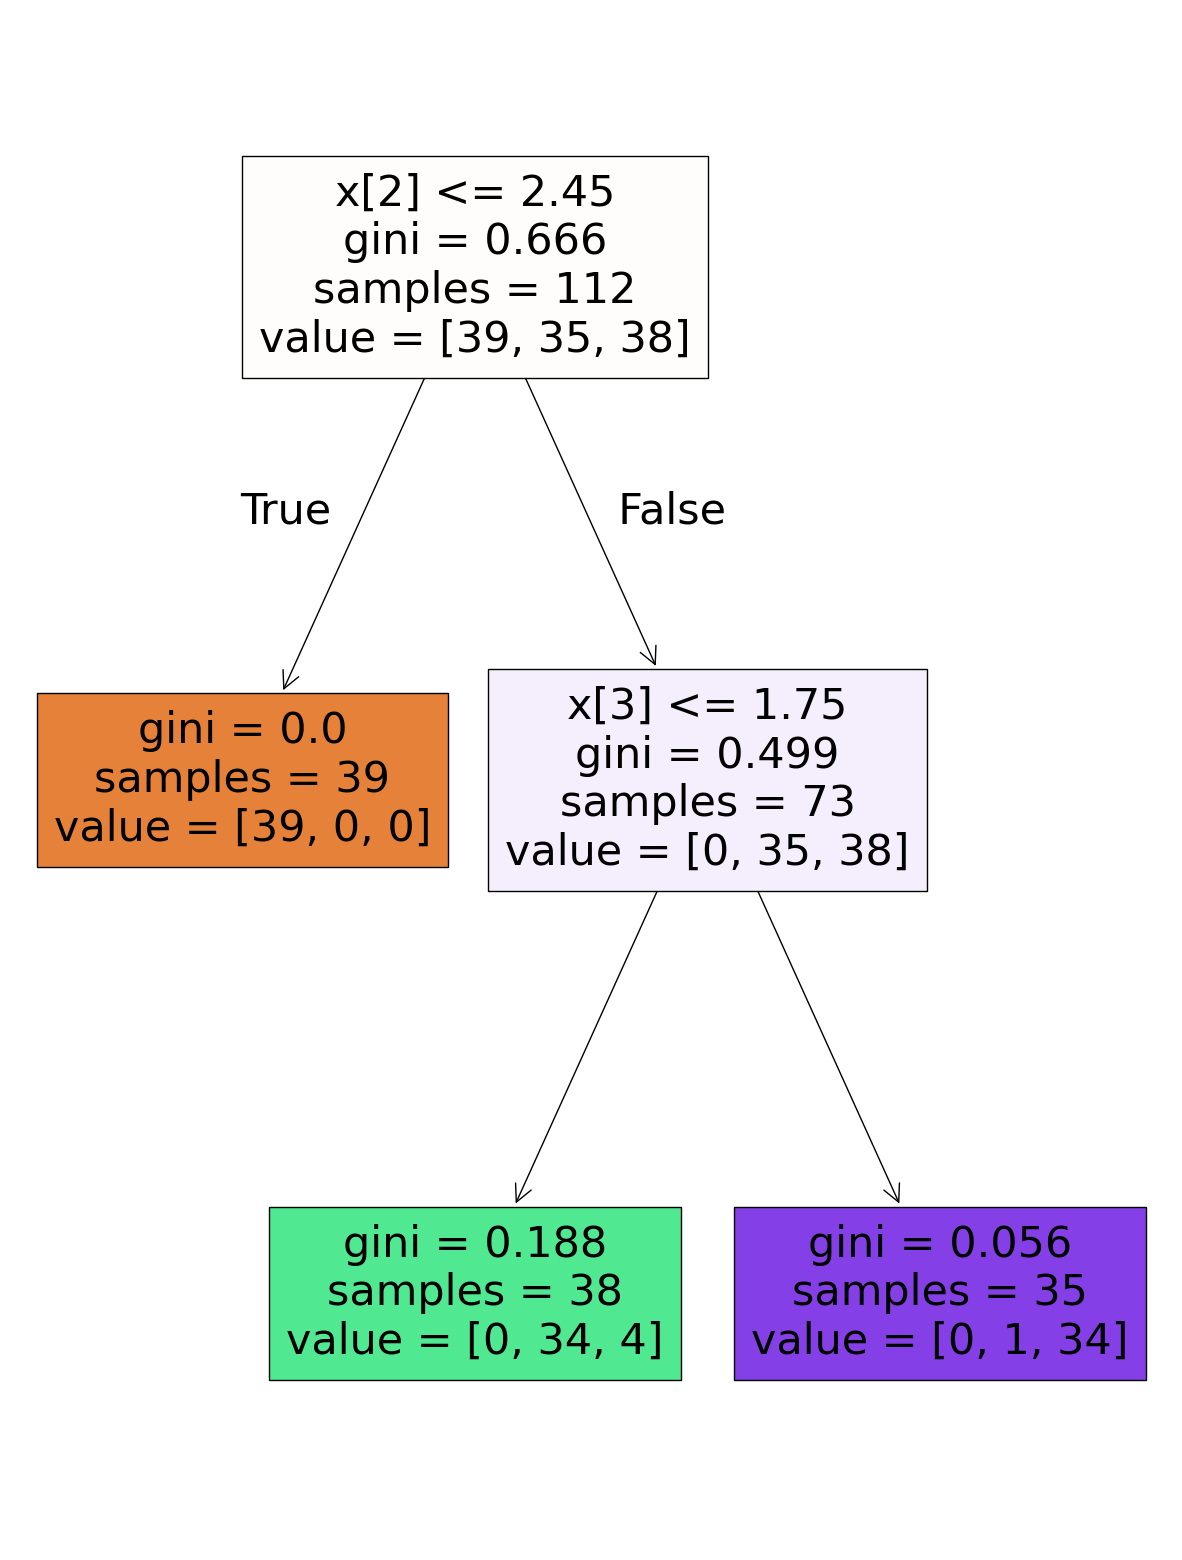

In [35]:
from sklearn import tree
plt.figure(figsize=(15,20))
tree.plot_tree(dtc,filled=True)
plt.show()

In [ ]:
DecisionTreeClassifier

### Decision Tree and PrePrunning

In [37]:
params={
    'criterion' : ["gini", "entropy", "log_loss"],
    'splitter' : ["best", "random"]
}


In [38]:
from sklearn.model_selection import GridSearchCV
gsv=GridSearchCV(estimator=dtc,param_grid=params,scoring='accuracy',cv=5)

In [41]:
gsv.fit(xtrain,ytrain)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(max_depth=2),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [42]:
gsv.best_params_

{'criterion': 'gini', 'splitter': 'best'}

In [43]:
y_pred=gsv.predict(xtest)

In [46]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_pred,ytest))
print(classification_report(y_pred,ytest))


[[11  0  0]
 [ 0 15  1]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.94      0.97        16
           2       0.92      1.00      0.96        11

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

